## Objective

The goal of this project is to apply Deep Learning techniques to a problem different from the classic NLP classification tasks, such as Sentiment Analysis.

For this purpose, the dataset from the fifth edition of [EXIST: sEXism Identification in Social neTworks](https://nlp.uned.es/exist2025/), which was part of [CLEF 2025](https://clef2025.clef-initiative.eu/), has been selected. This competition focuses on detecting sexism in social networks. The task will therefore involve binary classification to identify tweets as sexist or non-sexist. A solution based on *Deep Learning* will be proposed through fine-tuning of a pre-trained Transformer model for Spanish, [BETO](https://huggingface.co/dccuchile/bert-base-spanish-wwm-uncased).

## Dataset Loading

First, the dataset will be loaded. The data paths are defined below, and since the official test set does not have labels, the development (dev) set has been designated as the evaluation set. As can be seen, the paths for the labels and the data containing the textual content (tweets) are separate due to the competition's task division.

In [1]:
import os

base = '2025 EXIST'
datasets_path = base + '/EXIST 2025 Tweets Dataset'
labels_path = base + '/evaluation/golds'

# ruta de los datos de entrenamiento y test
train_path = datasets_path + '/training/EXIST2025_training.json'
test_path = datasets_path + '/dev/EXIST2025_dev.json'

# ruta de las etiquetas de entrenamiento y test
train_labels_path = labels_path + '/EXIST2025_training_task1_1_gold_hard.json'
test_labels_path = labels_path + '/EXIST2025_dev_task1_1_gold_hard.json'

Once the paths are set, the training and test data, along with their labels, are loaded.

In [2]:
import pandas as pd

# cargar conjuntos de entrenamiento y test
train = pd.read_json(train_path, orient='index')
test = pd.read_json(test_path, orient='index')

# cargar las etiquetas de entrenamiento y test
train_labels = pd.read_json(train_labels_path)
test_labels = pd.read_json(test_labels_path)

Next, we can verify that the data has been loaded correctly, as well as check its format.

In [3]:
train.info()

<class 'pandas.DataFrame'>
Index: 6920 entries, 100001 to 203260
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   id_EXIST                 6920 non-null   int64 
 1   lang                     6920 non-null   str   
 2   tweet                    6920 non-null   str   
 3   number_annotators        6920 non-null   int64 
 4   annotators               6920 non-null   object
 5   gender_annotators        6920 non-null   object
 6   age_annotators           6920 non-null   object
 7   ethnicities_annotators   6920 non-null   object
 8   study_levels_annotators  6920 non-null   object
 9   countries_annotators     6920 non-null   object
 10  labels_task1_1           6920 non-null   object
 11  labels_task1_2           6920 non-null   object
 12  labels_task1_3           6920 non-null   object
 13  split                    6920 non-null   str   
dtypes: int64(2), object(9), str(3)
memory usage: 810.

In [4]:
train.head(2)

,id_EXIST,lang,tweet,number_annotators,annotators,gender_annotators,age_annotators,ethnicities_annotators,study_levels_annotators,countries_annotators,labels_task1_1,labels_task1_2,labels_task1_3,split
100001,100001,es,"@TheChiflis Ignora al otro, es un capullo.El p...",6,"[Annotator_1, Annotator_2, Annotator_3, Annota...","[F, F, F, M, M, M]","[18-22, 23-45, 46+, 46+, 23-45, 18-22]","[White or Caucasian, Hispano or Latino, White ...","[Bachelor’s degree, Bachelor’s degree, High sc...","[Italy, Mexico, United States, Spain, Spain, C...","[YES, YES, NO, YES, YES, YES]","[REPORTED, JUDGEMENTAL, -, REPORTED, JUDGEMENT...","[[OBJECTIFICATION], [OBJECTIFICATION, SEXUAL-V...",TRAIN_ES
100002,100002,es,@ultimonomada_ Si comicsgate se parece en algo...,6,"[Annotator_7, Annotator_8, Annotator_9, Annota...","[F, F, F, M, M, M]","[18-22, 23-45, 46+, 46+, 23-45, 18-22]","[Black or African American, Hispano or Latino,...","[High school degree or equivalent, Bachelor’s ...","[United Kingdom, Mexico, United States, Portug...","[NO, NO, NO, NO, YES, NO]","[-, -, -, -, DIRECT, -]","[[-], [-], [-], [-], [OBJECTIFICATION], [-]]",TRAIN_ES


In [5]:
test.info()

<class 'pandas.DataFrame'>
Index: 1038 entries, 300001 to 400489
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   id_EXIST                 1038 non-null   int64 
 1   lang                     1038 non-null   str   
 2   tweet                    1038 non-null   str   
 3   number_annotators        1038 non-null   int64 
 4   annotators               1038 non-null   object
 5   gender_annotators        1038 non-null   object
 6   age_annotators           1038 non-null   object
 7   ethnicities_annotators   1038 non-null   object
 8   study_levels_annotators  1038 non-null   object
 9   countries_annotators     1038 non-null   object
 10  labels_task1_1           1038 non-null   object
 11  labels_task1_2           1038 non-null   object
 12  labels_task1_3           1038 non-null   object
 13  split                    1038 non-null   str   
dtypes: int64(2), object(9), str(3)
memory usage: 121.

In [6]:
test.head(2)

,id_EXIST,lang,tweet,number_annotators,annotators,gender_annotators,age_annotators,ethnicities_annotators,study_levels_annotators,countries_annotators,labels_task1_1,labels_task1_2,labels_task1_3,split
300001,300001,es,@Fichinescu La comunidad gamer es un antro de ...,6,"[Annotator_726, Annotator_727, Annotator_357, ...","[F, F, F, M, M, M]","[18-22, 23-45, 46+, 18-22, 23-45, 46+]","[Hispano or Latino, Hispano or Latino, White o...","[High school degree or equivalent, Bachelor’s ...","[Mexico, Chile, Serbia, Portugal, Mexico, Spain]","[NO, YES, YES, NO, YES, NO]","[-, JUDGEMENTAL, JUDGEMENTAL, -, REPORTED, -]","[[-], [MISOGYNY-NON-SEXUAL-VIOLENCE], [MISOGYN...",DEV_ES
300002,300002,es,@anacaotica88 @MordorLivin No me acuerdo de lo...,6,"[Annotator_731, Annotator_732, Annotator_315, ...","[F, F, F, M, M, M]","[18-22, 23-45, 46+, 18-22, 23-45, 46+]","[White or Caucasian, Hispano or Latino, White ...","[High school degree or equivalent, Bachelor’s ...","[Spain, Chile, United Kingdom, Chile, Chile, S...","[YES, YES, NO, YES, YES, YES]","[JUDGEMENTAL, REPORTED, -, JUDGEMENTAL, JUDGEM...","[[IDEOLOGICAL-INEQUALITY, STEREOTYPING-DOMINAN...",DEV_ES


In [7]:
train_labels.info()

<class 'pandas.DataFrame'>
RangeIndex: 6064 entries, 0 to 6063
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   test_case  6064 non-null   str  
 1   id         6064 non-null   int64
 2   value      6064 non-null   str  
dtypes: int64(1), str(2)
memory usage: 142.3 KB


In [8]:
train_labels.head(2)

,test_case,id,value
0,EXIST2025,100001,YES
1,EXIST2025,100002,NO


In [9]:
test_labels.info()

<class 'pandas.DataFrame'>
RangeIndex: 934 entries, 0 to 933
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   test_case  934 non-null    str  
 1   id         934 non-null    int64
 2   value      934 non-null    str  
dtypes: int64(1), str(2)
memory usage: 22.0 KB


In [10]:
test_labels.head(2)

,test_case,id,value
0,EXIST2025,300002,YES
1,EXIST2025,300003,NO


A portion of both sets are in English, a language that will not be addressed in this task since the objective is to classify tweets in Spanish. This will reduce the training data and, therefore, can be a factor that, above all, may affect the performance of the *Deep Learning* models.

On the other hand, irrelevant columns can be removed, leaving only id_EXIST to identify the tweet, the textual content itself in the ``tweet`` attribute, and ``value``, which is the label indicating whether the tweet is sexist or not.

In [11]:
# filtrar solo los twits en espanol
train = train[train['lang'] == 'es']
test = test[test['lang'] == 'es']

# filtrar solo las etiquetas de los datos restantes
train_labels = train_labels[train_labels['id'].isin(train['id_EXIST'])]
test_labels = test_labels[test_labels['id'].isin(test['id_EXIST'])]

In [12]:
# unir tweets con sus etiquetas en un solo DataFrame
train = pd.merge(train, train_labels, left_on='id_EXIST', right_on='id')
test = pd.merge(test, test_labels, left_on='id_EXIST', right_on='id')

# eliminar las columnas innecesarias
train = train[['id_EXIST', 'tweet', 'value']]
test = test[['id_EXIST', 'tweet', 'value']]

Once only the necessary data remains, we can see how many rows are left:

In [13]:
print(f'Filas del conjunto de entrenamiento: {len(train)}')
print(f'Filas del conjunto de test: {len(test)}')

Filas del conjunto de entrenamiento: 3194
Filas del conjunto de test: 490


As we can see, both sets have been reduced to just under half their original size. This may affect the balance of both classes, so we must check whether there is a similar proportion of each:

In [14]:
train['value'].value_counts(normalize=True)

value
NO     0.511584
YES    0.488416
Name: proportion, dtype: float64

As can be seen, the data is balanced, with 51% of tweets labeled as non-sexist and 48% as sexist.

## Preprocessing

The next stage will be to apply preprocessing to the tweet texts from both retrieved datasets (training and test). First, hashtag segmentation is proposed, as hashtags can be fundamental in identifying the theme and intention of each text.

Separating a hashtag like ``#NiUnaMenos`` helps to better focus the relationship between ``ni`` and ``menos``, capturing the sentiment of protest. To perform this task, the ekphrasis library will be used with a corpus extracted from Twitter, resulting in the following function:

In [15]:
from ekphrasis.classes.segmenter import Segmenter
seg = Segmenter(corpus="twitter")

def segment_hashtag(match):
    # obtener contenido del hashtag sin el '#'
    hashtag_content = match.group(1)
    # Segmentar (ej: "UnTexto" -> "un texto")
    segmented = seg.segment(hashtag_content)
    return segmented

Reading twitter - 1grams ...
Reading twitter - 2grams ...


c:\Users\filipondios\Desktop\exist2025\env\Lib\site-packages\ekphrasis\classes\exmanager.py:14: FutureWarning: Possible nested set at position 42
  regexes = {k.lower(): re.compile(self.expressions[k]) for k, v in


In Twitter texts, it is common to find user mentions using ``@user``, so we have chosen to replace these mentions with the string ``[USER]`` to maintain the user-topic relationship.

On the other hand, mentions, text, and hashtags are often found 'glued' together, such as ``text#hashtag`` or ``@user#hashtag``, which must be separated in order to process them individually. URLs have also been found in the tweets, which have been replaced with the string ``[URL]``.

In [16]:
import re

def preprocess(text: str):
    # separar hashtags y menciones pegadas
    text = re.sub(r'([^\s])([#@])', r'\1 \2', text)

    # sustituir las URLs del texto por [URL], primero
    # separando las que estan pegadas en el texto
    text =  re.sub(r'(\w+)(https?://)', r'\1 \2', text)
    text = re.sub(r'https?://[^\s]+', '[URL]', text)

    # sustituir menciones a usuarios por [USER]
    text = re.sub(r'@\w+', '[USER]', text)

    # quitar el '#' de los hashtags y segmentarlos
    text = re.sub(r'#(\w+)', segment_hashtag, text)
    return text

Once the preprocessing function is ready, new columns are created with the cleaned text.

In [17]:
# preprocesar el conjunto de entrenamiento y test
train['tweet_clean'] = train['tweet'].apply(preprocess)
test['tweet_clean'] = test['tweet'].apply(preprocess)

First, the axes for the training and test sets are obtained. The X-axis will be the tweet texts, while the Y-axis will be the labels.

In [18]:
# obtener los ejes x,y
x_train = train['tweet_clean']
y_train = train['value']

x_test = test['tweet_clean']
y_test = test['value']

## DL Models

Since it will be needed later, dictionaries are computed to convert from labels to numbers and vice versa:

In [19]:
label2id = {'NO': 0, 'YES': 1}
id2label = {0: 'NO', 1: 'YES'}

y_train_dl = y_train.map(label2id)
y_test_dl = y_test.map(label2id)

Once we have the tools, it's time to specify the DL model that will undergo fine-tuning. This will be [BETO](https://huggingface.co/dccuchile/bert-base-spanish-wwm-cased). This model is of type [BERT](https://github.com/google-research/bert) (Bidirectional Encoder Representations from Transformers), specifically trained on Spanish, specifically the ``bert-base-spanish-wwm-cased model`` for lowercase and uppercase texts.

Next, a class must be defined so that PyTorch can access the dataset. Specifically, this class acts as an interface between the data (a Pandas DataFrame) and the Deep Learning model (BETO).

In [20]:
import torch

class EXISTDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels.tolist()

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

Once this class is available, the training and test data are encapsulated.

In [21]:
from transformers import AutoTokenizer

# obtener el tokenizador a partir del modelo
model_name = 'dccuchile/bert-base-spanish-wwm-cased'
tokenizer = AutoTokenizer.from_pretrained(model_name)

# tokenizar datos de entrenamiento y test
train_encodings = tokenizer(x_train.tolist(), truncation=True, 
    padding=True, max_length=128)

test_encodings = tokenizer(x_test.tolist(), truncation=True,
    padding=True, max_length=128)

# encapsular los datos de entrenamiento y test tokenizados
train_dataset = EXISTDataset(train_encodings, y_train_dl)
test_dataset = EXISTDataset(test_encodings, y_test_dl)

c:\Users\filipondios\Desktop\exist2025\env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Before training the model, the following function is defined to calculate the ``Precision``, ``Recall``, and ``F1`` metrics, which will help evaluate the model.

In [22]:
from sklearn.metrics import precision_recall_fscore_support, accuracy_score
import numpy as np

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=1)
    
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, predictions, average='binary')
    acc = accuracy_score(labels, predictions)

    return { 'accuracy': acc, 'f1': f1, 
        'precision': precision, 'recall': recall }

Now, we download the BETO model from the internet or load it from disk.

In [23]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    model_name, num_labels=2, id2label=id2label, label2id=label2id)

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 38079.08it/s]
BertForSequenceClassification LOAD REPORT from: dccuchile/bert-base-spanish-wwm-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
bert.pooler.dense.bias                     | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECT

Once the model is loaded, the arguments to be used by the model during training must be defined. Among the most notable parameters is the number of epochs, set to 3. Since the model is already pre-trained and overfitting is to be avoided, it is set to a low value to prevent it from 'memorizing' the dataset.

In [24]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=64,
    warmup_steps=500,
    weight_decay=0.01,
    logging_steps=10,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True
)

In [25]:
from transformers import Trainer

trainer = Trainer(model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics)
trainer.train()

c:\Users\filipondios\Desktop\exist2025\env\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.427923,0.405029,0.818367,0.835490,0.807143,0.865900
2,0.296945,0.414196,0.834694,0.833676,0.898230,0.777778
3,0.286158,0.567006,0.818367,0.828516,0.833333,0.823755


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.33it/s]
c:\Users\filipondios\Desktop\exist2025\env\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.41it/s]
c:\Users\filipondios\Desktop\exist2025\env\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.19it/s]
There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer

TrainOutput(global_step=600, training_loss=0.3899756222963333, metrics={'train_runtime': 2902.271, 'train_samples_per_second': 3.302, 'train_steps_per_second': 0.207, 'total_flos': 600738039375120.0, 'train_loss': 0.3899756222963333, 'epoch': 3.0})

Once the model is trained, we make predictions on the test set:

In [26]:
import numpy as np

predictions = trainer.predict(test_dataset)
y_pred = np.argmax(predictions.predictions, axis=1)
y_true = predictions.label_ids

c:\Users\filipondios\Desktop\exist2025\env\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


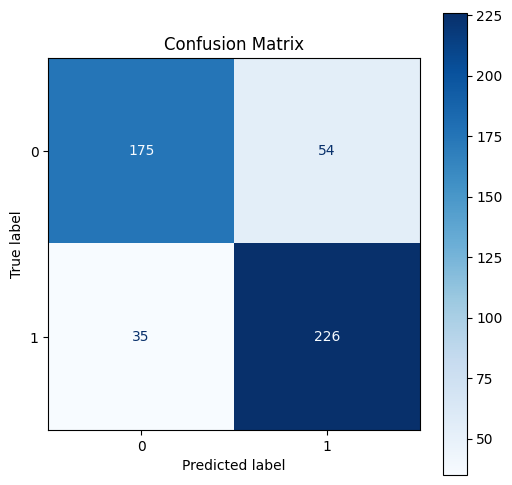

              precision    recall  f1-score   support

           0       0.83      0.76      0.80       229
           1       0.81      0.87      0.84       261

    accuracy                           0.82       490
   macro avg       0.82      0.82      0.82       490
weighted avg       0.82      0.82      0.82       490



In [27]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

# show the predictions confusion matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
fig, ax = plt.subplots(figsize=(6,6))
disp.plot(ax=ax, cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

# report: precission, recall, f1 and support
print(classification_report(y_true, y_pred))

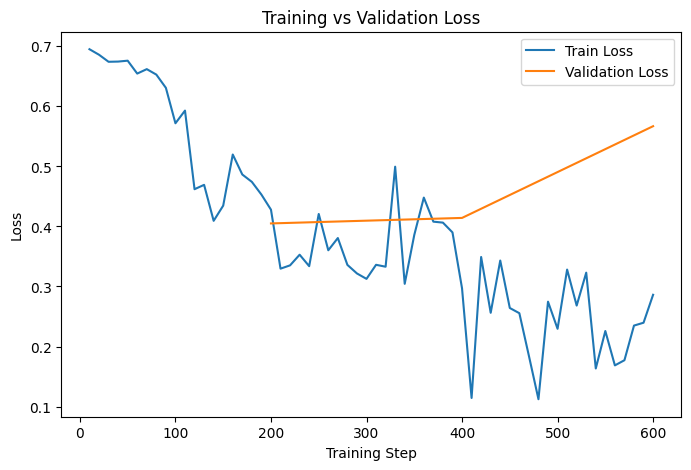

In [28]:
logs = pd.DataFrame(trainer.state.log_history)
train_loss = logs[logs.loss.notna()]
eval_loss = logs[logs.eval_loss.notna()]

plt.figure(figsize=(8,5))
plt.plot(train_loss.step, train_loss.loss, label='Train Loss')
plt.plot(eval_loss.step, eval_loss.eval_loss, label='Validation Loss')
plt.xlabel('Training Step'); plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend(); plt.show()

It can be observed that the model suffers from overfitting in the third epoch, which could be affecting performance. Even so, it achieves quite solid results (84% in F1). Next, a final model will be tested with 2 epochs instead of 3.

In [29]:
model = AutoModelForSequenceClassification.from_pretrained(
    model_name, num_labels=2, id2label=id2label, label2id=label2id)

training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=2,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=64,
    warmup_steps=500,
    weight_decay=0.01,
    logging_steps=10,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True
)

trainer = Trainer(model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics)
trainer.train()

Loading weights: 100%|██████████| 197/197 [00:00<?, ?it/s]
BertForSequenceClassification LOAD REPORT from: dccuchile/bert-base-spanish-wwm-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
bert.pooler.dense.bias                     | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be 

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.441269,0.420416,0.806122,0.830054,0.778523,0.888889
2,0.358472,0.411921,0.814286,0.819802,0.848361,0.793103


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.74it/s]
c:\Users\filipondios\Desktop\exist2025\env\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.01it/s]
There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer

TrainOutput(global_step=400, training_loss=0.46993446588516236, metrics={'train_runtime': 1942.5665, 'train_samples_per_second': 3.288, 'train_steps_per_second': 0.206, 'total_flos': 400492026250080.0, 'train_loss': 0.46993446588516236, 'epoch': 2.0})

In [30]:
predictions = trainer.predict(test_dataset)
y_pred = np.argmax(predictions.predictions, axis=1)
y_true = predictions.label_ids

c:\Users\filipondios\Desktop\exist2025\env\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


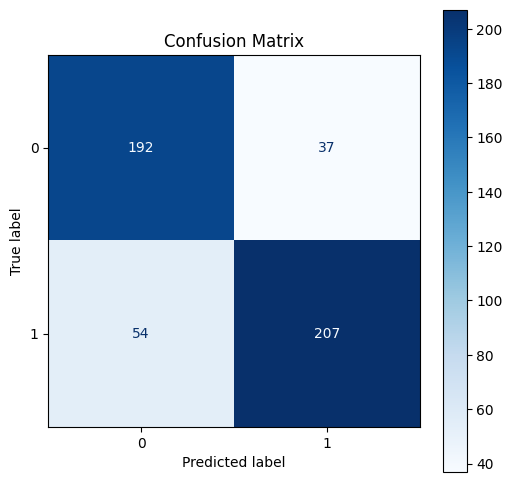

              precision    recall  f1-score   support

           0       0.78      0.84      0.81       229
           1       0.85      0.79      0.82       261

    accuracy                           0.81       490
   macro avg       0.81      0.82      0.81       490
weighted avg       0.82      0.81      0.81       490



In [31]:
# show the predictions confusion matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
fig, ax = plt.subplots(figsize=(6,6))
disp.plot(ax=ax, cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

# report: precission, recall, f1 and support
print(classification_report(y_true, y_pred))

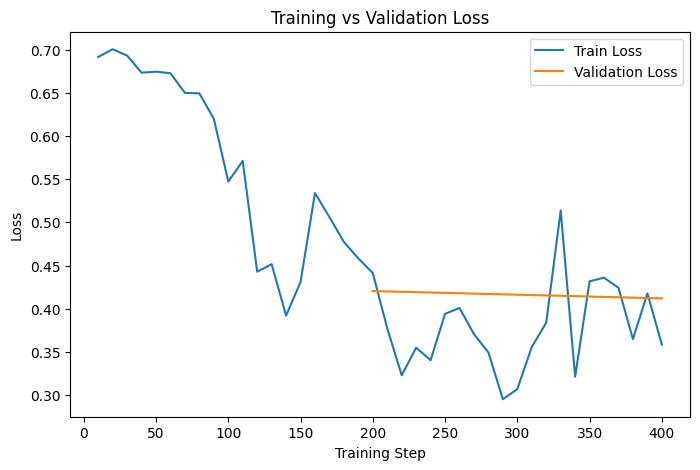

In [32]:
logs = pd.DataFrame(trainer.state.log_history)
train_loss = logs[logs.loss.notna()]
eval_loss = logs[logs.eval_loss.notna()]

plt.figure(figsize=(8,5))
plt.plot(train_loss.step, train_loss.loss, label='Train Loss')
plt.plot(eval_loss.step, eval_loss.eval_loss, label='Validation Loss')
plt.xlabel('Training Step'); plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend(); plt.show()

Not only do the results not improve, but they worsen when reducing the number of epochs, achieving 81% in F1. Even so, the model probably reaches its optimal point around epoch 2. The data memorization that occurred in the previous model during the third epoch somehow helped it evaluate the test set more accurately, although this does not necessarily mean it would be more effective in a real-world scenario.

On the other hand, in the last graph, the training loss decreases with some variability and the validation loss remains quite stable, which could be due to the validation set being relatively small and the model converging quickly.

## Error Analysis

Finally, it is interesting to see what types of tweets the model made mistakes on, both for false positives and false negatives. First, all errors are collected:

In [33]:
error_df = test.copy()
error_df['true_label'] = y_true
error_df['predicted_label'] = y_pred
error_df = error_df[['tweet_clean', 'true_label', 'predicted_label']]
error_df.head(10)

,tweet_clean,true_label,predicted_label
0,[USER] [USER] No me acuerdo de los detalles de...,1,1
1,[USER] lo digo cada pocos dias y lo repito: TO...,0,0
2,Also mientras les decia eso la señalaba y deci...,1,1
3,"And all people killed, attacked, harassed by ...",0,0
4,On this world press freedom day I’m thinking o...,0,0
5,[USER] [USER] [USER] [USER] [USER] La izquierd...,1,1
6,[USER] [USER] Uyyy a q huele? Apesta a xenofob...,1,1
7,Con 25 Leones🦁 y 500 más en las gradas🗣!! eko ...,0,0
8,[USER] [USER] [USER] Me gustaría saber que fut...,1,1
9,[USER] El hombre perfecto para estas mujeres s...,1,1


### False Positives

False positives will be those tweets that are not sexist but the model marked as sexist:

In [34]:
pd.set_option('display.max_colwidth', None)
false_positives = error_df[(error_df.true_label == 0) & (error_df.predicted_label == 1)]
print(f'Número de falsos positivos: {len(false_positives)}')
false_positives.head(10)

Número de falsos positivos: 37


,tweet_clean,true_label,predicted_label
21,"[USER] tal cual, rompemos el obelisco, quemamos muñecos con la cara de Jake Gyllenhaal al grito de you were tossing me the car keys fuck the patriarchy key chain on the ground y agarrate cuando arranque con dear John te traigo la cabeza de ese en una pica",0,1
22,Agarré un desodorante sin querer que se llama Patrichs y pensé que decía Patriarchy jajsjsj olor a VARON,0,1
34,"Si usted está pensando en votar r3chazo, le recuedo que Cecila Morel, ex primera dama, le da miedito que se deje de abusar del pueblo, por que ella dijo...“Vamos a tener que disminuir nuestros privilegios y compartir con los demás”...con que dejen de robar ya estariamos!",0,1
38,"[USER] Que no somos animales para reproducirnos sin consciencia, dejando vástagos por el mundo sin preocuparnos de lo que han de vestir, comer y recibir como educación. Una ""sobrepoblación"" de un hogar espiritual y materialmente inadecuado puede ser causa de males como el abuso sexual.",0,1
48,"[USER] CalvoAh diablos no me denuncies por acoso sexual 😭😭Pero fuera bromas, que tiene que ver una cosa con la otra yo tampoco entiendo nada tiene sentido [URL]",0,1
49,Dios mío oh padre libranos cada día de:°Los accidentes automovilístico. °Los robos.°El acoso.°La infidelidad. °El homicidio/ feminicidio. °El abuso policial.°El abuso. °El desempleo.°El secuestro en Haití.°La guerra de Putin con Ucrania.°Los desastres naturales.,0,1
62,"[USER] [USER] si asesinar mujeres embarazadas , bombardear niños y sacar los ojos a estudiantes, pero con los actores armados si son cagado no a otro perro con ese hueso",0,1
82,Os confieso q cada vez q veo una foto de orslok 2015 se me caen las bragas,0,1
98,alguien de cadiz capital q busque compañera d piso o chacha d la limpieza solo necesito cama y ducha el resto me apaño,0,1
100,"Que difícil tener a chacha en face, todas las semanas tengo que adivinar quien es el nuevo perfil con nombre raro😂",0,1


### False Negatives

On the other hand, false negatives are those tweets that are sexist but the model has labeled as non-sexist.

In [35]:
false_negatives = error_df[(error_df.true_label == 1) & (error_df.predicted_label == 0)]
print(f'Número de falsos negativos: {len(false_negatives)}')
false_negatives.head(10)

Número de falsos negativos: 54


,tweet_clean,true_label,predicted_label
14,[USER] Micromachismo me recuerda a cuando en South park el directo PC gritaba MICROAGRESION!,1,0
20,"[USER] 22 años, posiblemente una bufanda roja, QUIEN TE LASTIMÓ MAR???? DECINOS QUE LO AGARRAMOS, FUCK THE PATRIARCHY ah",1,0
30,"Absuelto, si, pero, quién le devuelve su vida?. Cuanto daño el pvto yo si te creo [USER] [USER] comunismo es miseria presunciondeinocenci a la reunion secreta [URL]",1,0
39,"ahora que me relaciono de una manera más libre y menos normativa sufro menos esas violencias sistemáticas del amor romántico, pero aún así sufro las secuelas de haber experimentado tanto abuso en el pasado",1,0
58,seguir idealizando y romantizando características sexo corporales adeptas al androcentrismo y a la masculinidad.,1,0
77,"en vivo Conferencia ""Barreras invisibles para madres trabajadoras"", impartida por la Mtra. Virginia Shaday Gutiérrez León [URL] [USER] [USER]",1,0
79,"""hip dips are ok &lt;3"" y sube una foto de sus hip dips casi imperceptibles pero con el polo todo subido para que se le vea la cinturita, el culaso y su thigh gap XDDD body positivity mis pelotas :)",1,0
80,Les encanta mamar de body positivity hasta que es alguien flacx. Dejen de opinar sobre el cuerpo de lxs demás🤫,1,0
89,"Brecha salarial de género, un reflejo de la sociedad. La visión de Fernanda Vicente y Desafío 10X.[URL] [URL]",1,0
91,"Lanzamos equi rutas con el propósito de incrementar la participación de las mujeres en el sector laboral, vinculación en cargos de liderazgo y reducir la brecha salarial de género. 👩🏽‍💼👩🏽‍💻¡Únete con tu organización a esta ipg! ➡️ [URL] [URL]",1,0


In both cases, there are tweets that could be interpreted as either label, as they are quite ambiguous cases that even a person might get wrong. Let's remember that there is no clear line between what is or isn't sexist, and in fact, the labels for each tweet are the result of a majority vote to avoid bias from a single person and thus have a better response to ambiguous cases.

## Conclusion

The transformer-based model achieves an F1-score of 0.83 on the test set, which indicates strong performance for the task of sexism detection in Spanish tweets.

The training dynamics show that the model quickly learns useful representations, with validation performance improving during the first two epochs. However, the increase in validation loss during the third epoch suggests the beginning of overfitting, indicating that two epochs may be sufficient for optimal generalization.

Error analysis reveals that most misclassifications occur in tweets where sexism is expressed implicitly, through irony, or in context-dependent statements. These cases are inherently difficult to detect because they require pragmatic or cultural understanding beyond the textual surface.

Furthermore, since the dataset annotations are based on majority voting among human annotators, some degree of subjectivity is inherent to the task. As a result, achieving perfect classification performance is unrealistic, and the obtained results represent a strong baseline for transformer-based approaches in this setting.